## 1. Methode : Entscheidungsbaum

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score, recall_score, f1_score,
                             roc_curve, roc_auc_score)

# Matplotlib setting for Jupyter Notebook
%matplotlib inline

In [2]:

# Setze den relativen Pfad zur Datei
dateipfad = os.path.join("/Users/I585032/Desktop/AI Data Analyst M1", "hotel_bookings_processed.csv")
df = pd.read_csv(dateipfad, sep=";")  # falls die processed auch mit ; gespeichert wurde
print(df.columns.tolist())



# df = df.drop('Unnamed: 0', axis=1)


# Entfernen von Spalten mit Dataleakage also spalten, die nicht für die Vorhersage verwendet werden können
notinuse_col =['reservation_status_date',
               'arrival_date_year',
               #'arrival_date_month',
               'arrival_date_week_number', 
               'assigned_room_type',
               'reservation_status',
               'arrival_date_day_of_month',
               'arrival_date']

df.drop(notinuse_col, axis = 1, inplace = True)


['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date', 'company_agent', 'arrival_date', 'company_agent_str']


In [5]:
# Vollständige Übersicht aller Variablen mit Eigenschaften und Datentypen
print(f"Anzahl der Spalten: {len(df.columns)}")
print(f"Anzahl der Zeilen: {len(df)}")
print("\n" + "="*80)
print("VOLLSTÄNDIGE VARIABLENÜBERSICHT")
print("="*80 + "\n")

# Detaillierte Informationen zu allen Spalten
variable_info = pd.DataFrame({
    'Variable': df.columns,
    'Datentyp': df.dtypes.values,
    'Nicht-Null': df.notna().sum().values,
    'Fehlend': df.isna().sum().values,
    'Unique': [df[col].nunique() for col in df.columns],
    'Min': [df[col].min() if df[col].dtype in ['int64', 'float64'] else '-' for col in df.columns],
    'Max': [df[col].max() if df[col].dtype in ['int64', 'float64'] else '-' for col in df.columns]
})

# Ausgabe der vollständigen Liste
print(variable_info.to_string(index=False))

# Zusätzliche Statistik nach Datentyp
print("\n" + "="*80)
print("ZUSAMMENFASSUNG NACH DATENTYP")
print("="*80)
print(df.dtypes.value_counts())

Anzahl der Spalten: 34
Anzahl der Zeilen: 119390

VOLLSTÄNDIGE VARIABLENÜBERSICHT

                      Variable Datentyp  Nicht-Null  Fehlend  Unique   Min      Max
                         hotel   object      119390        0       2     -        -
                   is_canceled    int64      119390        0       2     0        1
                     lead_time    int64      119390        0     479     0      737
             arrival_date_year    int64      119390        0       3  2015     2017
      arrival_date_week_number    int64      119390        0      53     1       53
     arrival_date_day_of_month    int64      119390        0      31     1       31
       stays_in_weekend_nights    int64      119390        0      17     0       19
          stays_in_week_nights    int64      119390        0      35     0       50
                        adults    int64      119390        0      14     0       55
                      children  float64      119390        0       5   0.0   

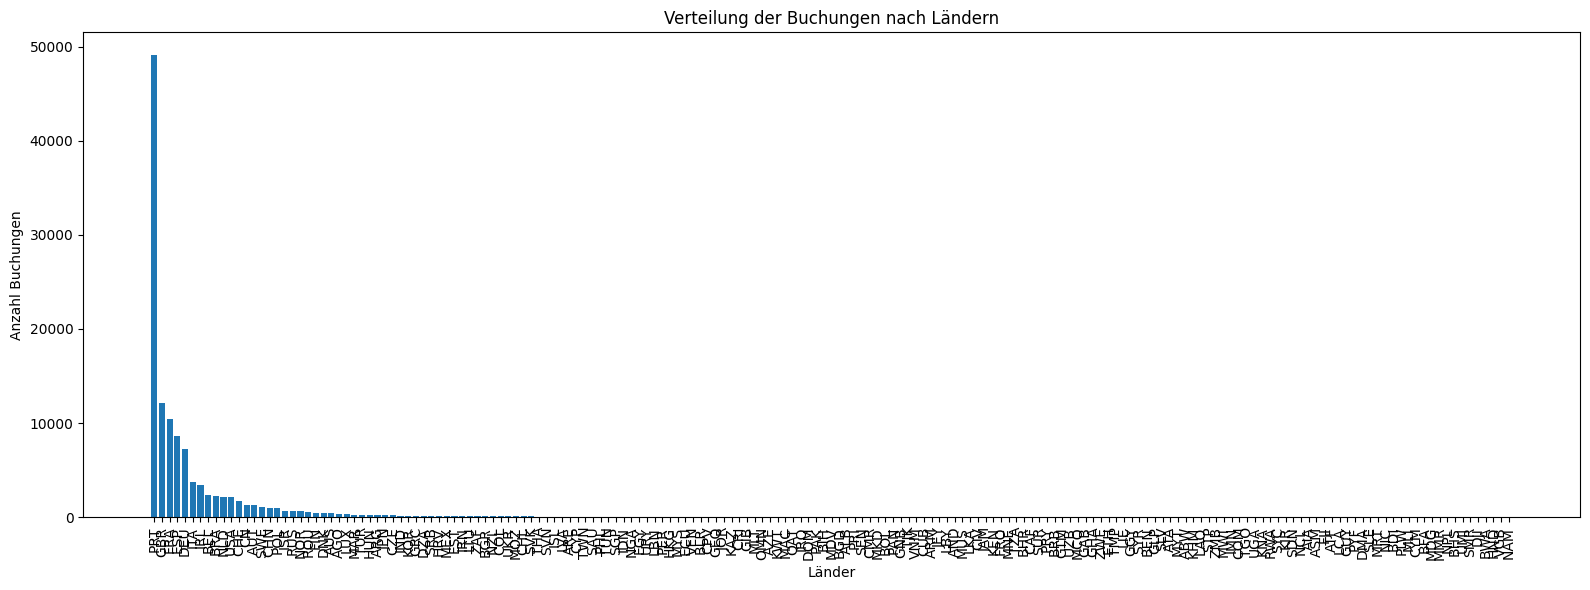

Anzahl unterschiedlicher Länder: 177

Top 10 Länder:
country
PRT    49078
GBR    12129
FRA    10415
ESP     8568
DEU     7287
ITA     3766
IRL     3375
BEL     2342
BRA     2224
NLD     2104
Name: count, dtype: int64
Anzahl der Länder nach Gruppierung: 15

Verteilung nach Gruppierung:
country
PRT          49078
GBR          12129
Sonstiges    11733
FRA          10415
ESP           8568
DEU           7287
ITA           3766
IRL           3375
BEL           2342
BRA           2224
NLD           2104
USA           2097
CHE           1730
CN            1279
AUT           1263
Name: count, dtype: int64


In [21]:
# Histogramm aller Länder erstellen
country_counts = df_raw['country'].value_counts()  # ← df_raw!

plt.figure(figsize=(16, 6))
plt.bar(range(len(country_counts)), country_counts.values)
plt.xlabel("Länder")
plt.ylabel("Anzahl Buchungen")
plt.title("Verteilung der Buchungen nach Ländern")
plt.xticks(range(len(country_counts)), country_counts.index, rotation=90)
plt.tight_layout()
plt.show()

print(f"Anzahl unterschiedlicher Länder: {len(country_counts)}")
print("\nTop 10 Länder:")
print(country_counts.head(10))

# Calculate the percentage of bookings for each country
country_percentages = (df_raw['country'].value_counts() / len(df_raw)) * 100  # ← df_raw!

# Identify countries with less than 1% of bookings
countries_below_1_percent = country_percentages[country_percentages < 1].index.tolist()

# Replace countries below 1% with 'Sonstiges' - ABER nur in df_raw!
df_raw['country'] = df_raw['country'].apply(lambda x: 'Sonstiges' if x in countries_below_1_percent else x)

print(f"Anzahl der Länder nach Gruppierung: {df_raw['country'].nunique()}")
print("\nVerteilung nach Gruppierung:")
print(df_raw['country'].value_counts())


In [22]:


categorical_cols = [col for col in df.columns if df[col].dtype == 'O']


# One-hot encoding for categorical variables
for var in categorical_cols:
    dummies = pd.get_dummies(df[var], prefix=var)
    df = pd.concat([df, dummies], axis=1)
    df.drop(var, axis=1, inplace=True)  


In [23]:
print(df.head())

   is_canceled  lead_time  arrival_date_year  arrival_date_week_number  \
0            0        342               2015                        27   
1            0        737               2015                        27   
2            0          7               2015                        27   
3            0         13               2015                        27   
4            0         14               2015                        27   

   arrival_date_day_of_month  stays_in_weekend_nights  stays_in_week_nights  \
0                          1                        0                     0   
1                          1                        0                     0   
2                          1                        0                     1   
3                          1                        0                     1   
4                          1                        0                     2   

   adults  children  babies  ...  arrival_date_2017-08-22  \
0       2       0.0

In [7]:
# --------------------------------------------------------------------
# 1) Feature-Matrix und Zielvariable definieren
# --------------------------------------------------------------------
X = df.drop('is_canceled', axis=1)  # Ersetze 'is_canceled' mit deinem Zielspaltennamen
y = df['is_canceled']               # Ersetze 'is_canceled' mit deinem Zielspaltennamen



In [8]:
# --------------------------------------------------------------------
# 2) Aufteilen in Trainings- und Testset
# --------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y  # Stratifizierung empfohlen bei Klassifikation
)


In [9]:
# --------------------------------------------------------------------
# 3) Klassifikationsbaum + Hyperparameter-Tuning mit GridSearchCV
# --------------------------------------------------------------------
classifier = DecisionTreeClassifier(random_state=42)

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# scoring='accuracy' ist eine übliche Metrik,
# du kannst aber auch 'f1' oder 'roc_auc' verwenden
grid_search = GridSearchCV(
    estimator=classifier,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    scoring='accuracy'
)

# GridSearchCV führt intern ein Fit durch, um das beste Modell zu finden.
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and

In [10]:
# --------------------------------------------------------------------
# 4) Bestes Modell auswählen
# --------------------------------------------------------------------
best_classifier = grid_search.best_estimator_

# best_estimator_ ist bereits auf den Trainingsdaten gefittet;
# falls du möchtest, kannst du noch einmal explizit fitten:
# best_classifier.fit(X_train, y_train)

print("Beste Hyperparameter:", grid_search.best_params_)
print("Bester CV-Score (Accuracy):", grid_search.best_score_)

Beste Hyperparameter: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2}
Bester CV-Score (Accuracy): 0.8394161556314664


In [11]:
# --------------------------------------------------------------------
# 5) Vorhersagen und Performance-Metriken
# --------------------------------------------------------------------
y_pred = best_classifier.predict(X_test)
print(y_test.value_counts())
print(y_pred.sum())
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Diverse Metriken
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

# Ausführlicheres Bericht
print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))



is_canceled
0    18792
1    11056
Name: count, dtype: int64
9915
Confusion Matrix:
 [[16932  1860]
 [ 3001  8055]]
Accuracy:  0.8371
Precision: 0.8124
Recall:    0.7286
F1-Score:  0.7682

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.90      0.87     18792
           1       0.81      0.73      0.77     11056

    accuracy                           0.84     29848
   macro avg       0.83      0.81      0.82     29848
weighted avg       0.84      0.84      0.84     29848



ROC-AUC: 0.9181


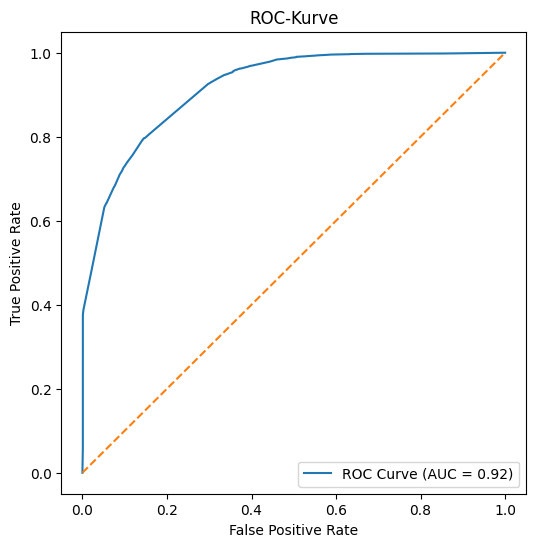

In [12]:
# --------------------------------------------------------------------
# 6) ROC-Kurve und AUC
# --------------------------------------------------------------------
# Da DecisionTreeClassifier eine Wahrscheinlichkeitsvorhersage liefern kann,
# nutzen wir predict_proba für die ROC-Kurve und den AUC-Wert.
y_proba = best_classifier.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_value = roc_auc_score(y_test, y_proba)

print(f"ROC-AUC: {auc_value:.4f}")

# Plot der ROC-Kurve
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc_value:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")  # Diagonale
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-Kurve")
plt.legend(loc="lower right")
plt.show()



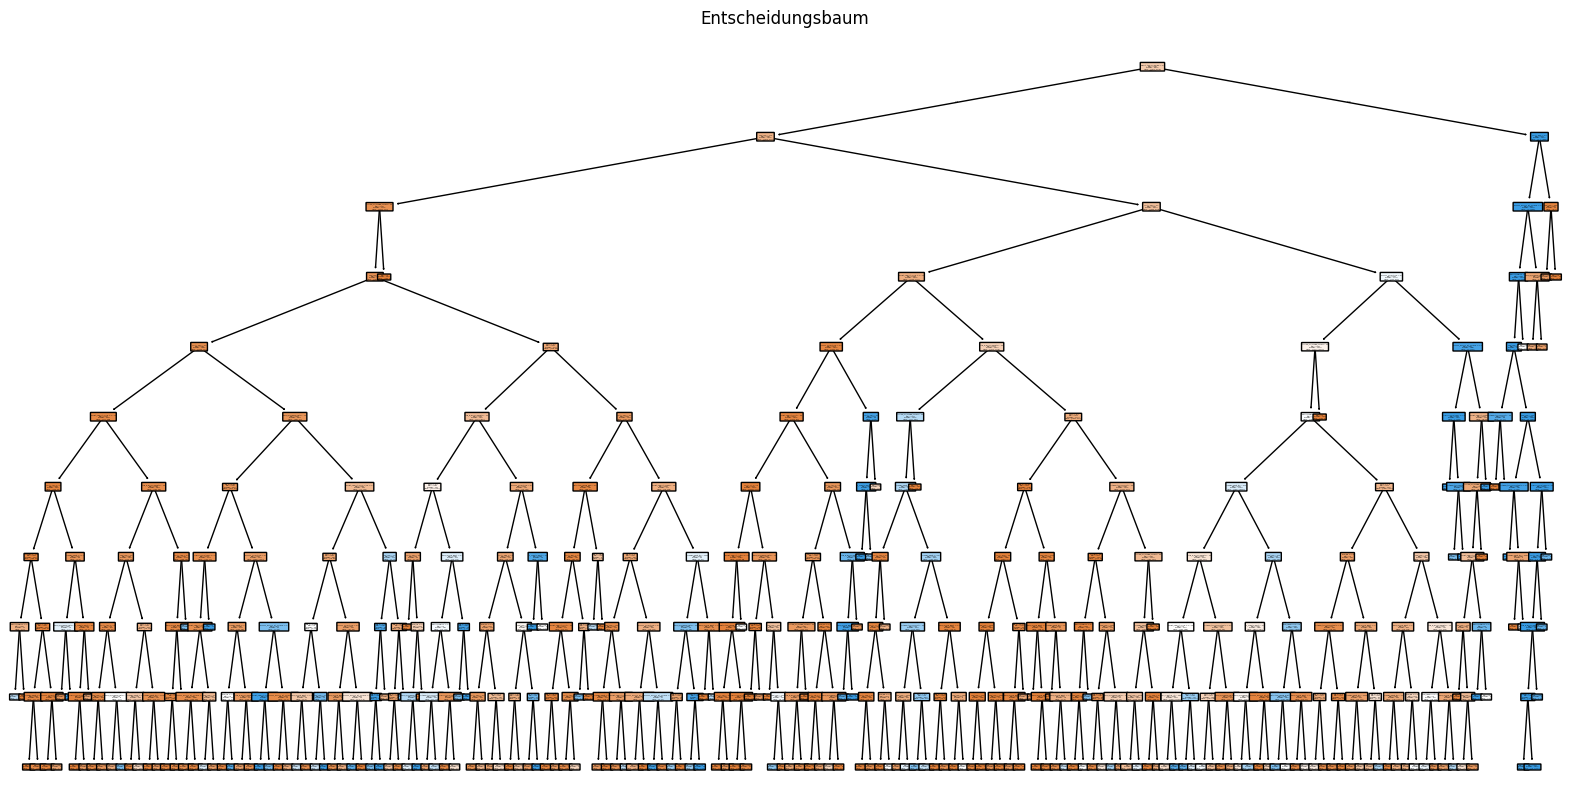

In [13]:
# --------------------------------------------------------------------
# 7) Entscheidungsbaum visualisieren (optional)
# --------------------------------------------------------------------
plt.figure(figsize=(20, 10))
plot_tree(best_classifier, filled=True, feature_names=X.columns, class_names=["0", "1"], rounded=True)
plt.title("Entscheidungsbaum")
plt.show()